# Step 1: Import Required Libraries

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import joblib
import warnings
warnings.filterwarnings("ignore")

### Observation

- All required libraries were imported successfully.
- Scikit-learn libraries will be used for feature extraction, model training, and evaluation.
- Joblib will be used to save the trained model and TF-IDF vectorizer.

# Step 2: Load the Processed Dataset

In [26]:
df = pd.read_csv("../data/processed_twitter_disaster.csv")

print("✅ Processed dataset loaded successfully.")

df.head()

✅ Processed dataset loaded successfully.


,id,keyword,location,text,target,tweet_length,sentiment
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1,69,NEGATIVE
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1,38,NEGATIVE
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1,133,NEGATIVE
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1,65,NEGATIVE
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1,88,NEGATIVE


### Observation

- The processed dataset was loaded successfully.
- The dataset includes the cleaned tweet information along with the sentiment feature generated using Hugging Face.
- This dataset will be used for model training.

# Step 3: Select Features and Target

In [27]:
# Select input feature and target variable

X = df["text"]
y = df["target"]

print("Number of Tweets :", len(X))
print("Number of Labels :", len(y))

Number of Tweets : 7613
Number of Labels : 7613


### Observation

- The **text** column was selected as the input feature.
- The **target** column was selected as the output label.
- The dataset is now ready to be split into training and testing sets.

# Step 4: Encode Sentiment Labels

In [28]:
from sklearn.preprocessing import LabelEncoder

sentiment_encoder = LabelEncoder()

df["sentiment_encoded"] = sentiment_encoder.fit_transform(df["sentiment"])

df[["sentiment", "sentiment_encoded"]].head()

,sentiment,sentiment_encoded
0,NEGATIVE,0
1,NEGATIVE,0
2,NEGATIVE,0
3,NEGATIVE,0
4,NEGATIVE,0


### Observation

- The sentiment labels were converted into numerical values using LabelEncoder.
- This transformation makes the sentiment feature suitable for machine learning algorithms.
- The encoded sentiment feature will later be combined with TF-IDF text features.

# Step 5: Split the Dataset

In [29]:
X_text = df["text"]

X_sentiment = df["sentiment_encoded"]

y = df["target"]

X_train_text, X_test_text, X_train_sentiment, X_test_sentiment, y_train, y_test = train_test_split(
    X_text,
    X_sentiment,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Samples :", len(X_train_text))
print("Testing Samples :", len(X_test_text))

Training Samples : 6090
Testing Samples : 1523


### Observation

- The dataset was divided into training and testing sets.
- 80% of the data will be used for training and 20% for testing.
- Both the tweet text and encoded sentiment feature were split together while preserving the class distribution.

# Step 6: Convert Tweet Text into TF-IDF Features

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF Vectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

# Learn vocabulary from training data and transform it

X_train_tfidf = tfidf.fit_transform(X_train_text)

# Transform testing data

X_test_tfidf = tfidf.transform(X_test_text)

print("Training TF-IDF Shape :", X_train_tfidf.shape)
print("Testing TF-IDF Shape :", X_test_tfidf.shape)

Training TF-IDF Shape : (6090, 5000)
Testing TF-IDF Shape : (1523, 5000)


### Observation

- TF-IDF converted tweet text into numerical feature vectors.
- The vectorizer was fitted only on the training data to avoid data leakage.
- The same vocabulary was applied to transform the testing data.

# Step 7: Combine TF-IDF and Sentiment Features

In [31]:
from scipy.sparse import hstack

# Convert sentiment into column vectors

X_train_sentiment = X_train_sentiment.values.reshape(-1, 1)
X_test_sentiment = X_test_sentiment.values.reshape(-1, 1)

# Combine TF-IDF vectors with sentiment feature

X_train_final = hstack([X_train_tfidf, X_train_sentiment])

X_test_final = hstack([X_test_tfidf, X_test_sentiment])

print("Training Shape :", X_train_final.shape)
print("Testing Shape :", X_test_final.shape)

Training Shape : (6090, 5001)
Testing Shape : (1523, 5001)


### Observation

- The encoded sentiment feature was combined with the TF-IDF text features.
- This created a richer feature set by incorporating both textual information and sentiment.
- The final feature matrix will be used to train the machine learning model.

# Step 8: Train the Logistic Regression Model

In [32]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model

model = LogisticRegression(max_iter=1000)

# Train the model

model.fit(X_train_final, y_train)

print("✅ Logistic Regression model trained successfully!")

✅ Logistic Regression model trained successfully!


### Observation

- The Logistic Regression model was trained using the combined TF-IDF and sentiment features.
- The model learned the relationship between tweet content and disaster labels.
- This trained model will be used to classify unseen tweets.

# Step 9: Predict on the Test Dataset

In [33]:
# Predict on test data

y_pred = model.predict(X_test_final)

print("Prediction completed successfully!")

Prediction completed successfully!


### Observation

- Predictions were generated for all tweets in the testing dataset.
- The model assigned each tweet to either the Disaster or Non-Disaster class.
- These predictions will be compared with the actual labels to evaluate model performance.

# Step 10: Calculate Accuracy Score

In [34]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")

Accuracy : 0.8168


### Observation

- The accuracy score measures the overall prediction performance of the model.
- A higher accuracy indicates that the model correctly classified most tweets.
- This provides a quick overview of the model's effectiveness.

# Step 11: Generate Classification Report

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.90      0.85       869
           1       0.84      0.71      0.77       654

    accuracy                           0.82      1523
   macro avg       0.82      0.80      0.81      1523
weighted avg       0.82      0.82      0.81      1523



### Observation

- The classification report displays Precision, Recall, F1-Score, and Support.
- These metrics provide a detailed evaluation for both Disaster and Non-Disaster classes.
- The report helps identify how well the model performs on each category.

# Step 12: Generate Confusion Matrix

In [36]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[779  90]
 [189 465]]


### Observation

- The confusion matrix summarizes correct and incorrect predictions.
- It shows True Positives, True Negatives, False Positives, and False Negatives.
- This helps understand where the model makes prediction errors.

# Step 13: Visualize the Confusion Matrix

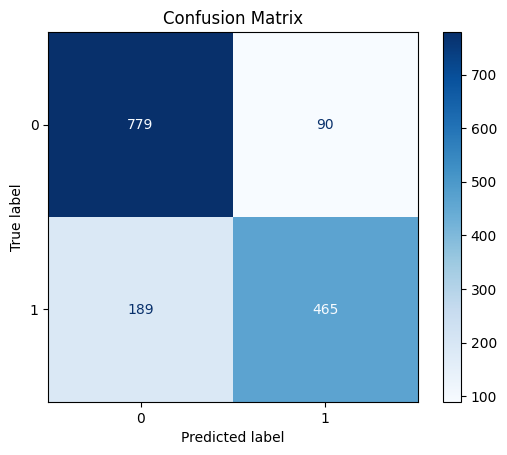

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

### Observation

- The confusion matrix was visualized using a heatmap.
- Darker cells represent a higher number of predictions.
- This visualization makes it easier to identify correct classifications and prediction errors.

# Step 14: Save the Trained Model

In [38]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/disaster_classifier.pkl")

print("✅ Model saved successfully!")

✅ Model saved successfully!


### Observation

- The trained Logistic Regression model was saved successfully.
- Saving the model allows it to be reused without retraining.
- This model will be loaded later in the Streamlit dashboard for predictions.

# Step 15: Save the TF-IDF Vectorizer

In [39]:
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("✅ TF-IDF Vectorizer saved successfully!")

✅ TF-IDF Vectorizer saved successfully!


### Observation

- The TF-IDF vectorizer was saved successfully.
- The same vocabulary will be used to transform new tweets during prediction.
- Using the saved vectorizer ensures consistency between training and deployment.

# Final Summary

### Observation

- The Logistic Regression model was successfully trained using TF-IDF features combined with Hugging Face sentiment information.
- Model performance was evaluated using Accuracy, Classification Report, and Confusion Matrix.
- The trained model and TF-IDF vectorizer were saved for deployment in the Streamlit dashboard.
- The project is now ready for the deployment and testing phase.